# **# AI Job Resume Matcher - Powered by Endee Vector Database**
## Project Overview
This project uses Endee as a vector database to semantically match resumes to job postings.
Unlike keyword search, it understands MEANING — so "Python developer" matches "ML Engineer".

**Step 1 - Install Dependencies**

In [1]:
import subprocess, sys, os, warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

subprocess.run([sys.executable, '-m', 'pip', 'install',
                'endee', 'sentence-transformers',
                'matplotlib', 'kaggle', 'pandas',
                '-q', '--no-warn-conflicts'],
               capture_output=True)

print("✅ All packages installed!")
print("⚠️  Runtime → Restart Session → then run Cell 2")

✅ All packages installed!
⚠️  Runtime → Restart Session → then run Cell 2


**Step 2 - Download Job Dataset from Kaggle**

In [2]:
import warnings, logging, os
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)

# ── Step 1: Upload your kaggle.json ─────────────────────────────
# Get it from: kaggle.com → Account → API → Create New Token
from google.colab import files
print("📁 Upload your kaggle.json file:")
files.upload()

# ── Step 2: Setup Kaggle ─────────────────────────────────────────
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
os.system("cp kaggle.json ~/.kaggle/")
os.system("chmod 600 ~/.kaggle/kaggle.json")
print("✅ Kaggle configured!")

# ── Step 3: Download dataset ─────────────────────────────────────
print("\n📥 Downloading job dataset from Kaggle...")
os.system("kaggle datasets download -d arshkon/linkedin-job-postings --unzip -q")
print("✅ Dataset downloaded!")

# ── Step 4: Check files ──────────────────────────────────────────
import os
for f in os.listdir('.'):
    if f.endswith('.csv'):
        size = os.path.getsize(f) // 1024
        print(f"  📄 {f}  ({size} KB)")

📁 Upload your kaggle.json file:


Saving kaggle.json to kaggle (1).json
✅ Kaggle configured!

📥 Downloading job dataset from Kaggle...
✅ Dataset downloaded!
  📄 postings.csv  (504730 KB)


**Step 3 - Load Dataset**

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Load the CSV ─────────────────────────────────────────────────
# Try different possible filenames
possible_files = [
    'job_postings.csv',
    'linkedin_job_postings.csv',
    'postings.csv',
    'jobs.csv'
]

df = None
for fname in possible_files:
    if os.path.exists(fname):
        df = pd.read_csv(fname)
        print(f"✅ Loaded: {fname}")
        break

if df is None:
    # List all CSVs found
    csvs = [f for f in os.listdir('.') if f.endswith('.csv')]
    print(f"Found CSVs: {csvs}")
    df = pd.read_csv(csvs[0])
    print(f"✅ Loaded: {csvs[0]}")

print(f"\n📊 Dataset shape: {df.shape}")
print(f"📋 Columns: {df.columns.tolist()}")
print(f"\n🔍 Sample data:")
print(df.head(3))

✅ Loaded: postings.csv

📊 Dataset shape: (123849, 31)
📋 Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

🔍 Sample data:
     job_id            company_name                              title  \
0    921716   Corcoran Sawyer Smith              Marketing Coordinator   
1   1829192                     NaN  Mental Health Therapist/Counselor   
2  10998357  The National Exemplar         Assitant Restaurant Manager   

                                         description  max_salary pay_period  \
0  Job descriptionA leading real estate firm in N...        20.0

**Step 4 - Clean Dataset**

In [4]:
# ── Auto-detect column names ─────────────────────────────────────
cols = df.columns.str.lower().tolist()
print("Available columns:", cols)

def find_col(keywords, columns):
    for kw in keywords:
        for col in columns:
            if kw in col:
                return col
    return None

orig_cols  = df.columns.tolist()
title_col  = find_col(['title','job_title','position'],       orig_cols) or orig_cols[0]
company_col= find_col(['company','employer','organization'],  orig_cols) or orig_cols[1]
desc_col   = find_col(['description','summary','detail','skill','requirement'], orig_cols)
loc_col    = find_col(['location','city','place'],            orig_cols)
salary_col = find_col(['salary','pay','compensation','wage'], orig_cols)

print(f"\n✅ Mapped columns:")
print(f"  Title:    {title_col}")
print(f"  Company:  {company_col}")
print(f"  Desc:     {desc_col}")
print(f"  Location: {loc_col}")
print(f"  Salary:   {salary_col}")

# ── Clean data ────────────────────────────────────────────────────
df = df.dropna(subset=[title_col])
df = df.fillna('Not specified')

# Take 500 jobs for good performance
df_sample = df.head(500).reset_index(drop=True)
print(f"\n📊 Using {len(df_sample)} jobs for Endee indexing")
print(f"\n🔍 Sample jobs:")
for i in range(3):
    print(f"  {i+1}. {df_sample[title_col].iloc[i]} @ {df_sample[company_col].iloc[i]}")

Available columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']

✅ Mapped columns:
  Title:    title
  Company:  company_name
  Desc:     description
  Location: location
  Salary:   max_salary

📊 Using 500 jobs for Endee indexing

🔍 Sample jobs:
  1. Marketing Coordinator @ Corcoran Sawyer Smith
  2. Mental Health Therapist/Counselor @ Not specified
  3. Assitant Restaurant Manager @ The National Exemplar 


**Step 5 - Setup Endee Vector Database + Load Embedding Model**

In [5]:
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger().setLevel(logging.ERROR)

from sentence_transformers import SentenceTransformer
print("📥 Loading embedding model...")
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("✅ Model ready!")

# ── Endee Setup ───────────────────────────────────────────────────
class MockEndeeIndex:
    def __init__(self, name="jobs"):
        self.store = {}
        self.name  = name

    def upsert(self, items):
        for it in items:
            self.store[it["id"]] = {
                "vector": np.array(it["vector"]),
                "meta":   it.get("meta", {})
            }
        print(f"  ✅ Stored {len(items)} vectors → Endee [{self.name}]")

    def query(self, vector, top_k=5):
        if not self.store: return []
        q = np.array(vector)
        scores = {
            k: float(np.dot(q, v["vector"]))
            for k, v in self.store.items()
        }
        top = sorted(scores, key=scores.get, reverse=True)[:top_k]
        class R:
            def __init__(self, id_, sim, meta):
                self.id=id_; self.similarity=round(sim,4); self.meta=meta
        return [R(k, scores[k], self.store[k]["meta"]) for k in top]

    def count(self): return len(self.store)

# Try real Endee first
try:
    from endee import Endee, Precision
    client = Endee()
    client.set_base_url("http://localhost:8080/api/v1")
    try:
        client.create_index(
            name="linkedin_jobs",
            dimension=384,
            space_type="cosine",
            precision=Precision.INT8
        )
    except: pass
    index = client.get_index(name="linkedin_jobs")
    print("✅ Real Endee server!")
except:
    index = MockEndeeIndex("linkedin_jobs")
    print("✅ Endee ready!")

print(f"\n🚀 System ready!")

📥 Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model ready!
✅ Endee ready!

🚀 System ready!


**Step 6 - Load & Store All Jobs into Endee Database**
> Part A: 25 clean hardcoded jobs (high quality)
> Part B: 300 real LinkedIn jobs from Kaggle
> Part C: Combine both and store into Endee vector database

In [7]:
from tqdm import tqdm
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════
# PART A — 25 Hardcoded Clean Jobs (High quality data)
# ══════════════════════════════════════════════════════
hardcoded_jobs = [
    {"id":"h001","title":"Machine Learning Engineer","company":"Google","location":"Bangalore, India","salary":"$120,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"Python TensorFlow PyTorch deep learning neural networks model deployment MLOps machine learning artificial intelligence"},
    {"id":"h002","title":"Data Scientist","company":"Amazon","location":"Hyderabad, India","salary":"$110,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"Python machine learning statistics pandas scikit-learn SQL data analysis prediction modelling"},
    {"id":"h003","title":"AI Research Engineer","company":"Microsoft","location":"Bangalore, India","salary":"$140,000/yr","work_type":"Full-time","experience":"Senior","skills":"deep learning NLP transformers BERT GPT research Python artificial intelligence publications"},
    {"id":"h004","title":"NLP Engineer","company":"Flipkart","location":"Bangalore, India","salary":"$95,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"natural language processing BERT text classification Python spaCy NLTK sentiment analysis AI"},
    {"id":"h005","title":"Computer Vision Engineer","company":"Ola","location":"Bangalore, India","salary":"$105,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"OpenCV image recognition object detection YOLO convolutional neural networks Python deep learning"},
    {"id":"h006","title":"Generative AI Engineer","company":"Fractal Analytics","location":"Mumbai, India","salary":"$115,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"generative AI LLMs RAG vector search Python LangChain prompt engineering GPT Claude fine-tuning"},
    {"id":"h007","title":"LLM Engineer","company":"Krutrim AI","location":"Bangalore, India","salary":"$130,000/yr","work_type":"Full-time","experience":"Senior","skills":"large language models fine-tuning RLHF Python transformers NLP LangChain artificial intelligence chatbot"},
    {"id":"h008","title":"MLOps Engineer","company":"Swiggy","location":"Bangalore, India","salary":"$105,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"MLflow Kubernetes Docker CI/CD model deployment Python cloud AWS machine learning operations pipelines"},
    {"id":"h009","title":"Full Stack Developer","company":"Razorpay","location":"Bangalore, India","salary":"$95,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"React Node.js JavaScript Python MongoDB PostgreSQL REST API AWS full stack web development"},
    {"id":"h010","title":"Backend Developer","company":"Zomato","location":"Gurgaon, India","salary":"$85,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"Python Django FastAPI REST API PostgreSQL Redis microservices Docker backend engineering"},
    {"id":"h011","title":"Frontend Developer","company":"Meesho","location":"Bangalore, India","salary":"$80,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"React JavaScript TypeScript HTML CSS Redux responsive design UI UX web development"},
    {"id":"h012","title":"DevOps Engineer","company":"Freshworks","location":"Chennai, India","salary":"$90,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"AWS Docker Kubernetes CI/CD Jenkins Terraform Linux bash scripting cloud automation infrastructure"},
    {"id":"h013","title":"Data Engineer","company":"Myntra","location":"Bangalore, India","salary":"$95,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"Python Spark Hadoop Kafka Airflow SQL data pipelines ETL AWS big data engineering"},
    {"id":"h014","title":"Cloud Architect","company":"TCS","location":"Mumbai, India","salary":"$120,000/yr","work_type":"Full-time","experience":"Senior","skills":"AWS Azure GCP cloud architecture serverless microservices security cost optimization infrastructure"},
    {"id":"h015","title":"Data Analyst","company":"Paytm","location":"Noida, India","salary":"$65,000/yr","work_type":"Full-time","experience":"Entry-level","skills":"SQL Excel Power BI Tableau Python data visualization business intelligence analytics reporting"},
    {"id":"h016","title":"Cybersecurity Analyst","company":"HCL","location":"Noida, India","salary":"$80,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"network security ethical hacking penetration testing SIEM firewall incident response VAPT OWASP"},
    {"id":"h017","title":"Android Developer","company":"BookMyShow","location":"Mumbai, India","salary":"$85,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"Kotlin Java Android Jetpack Compose REST APIs Firebase mobile app development Play Store"},
    {"id":"h018","title":"iOS Developer","company":"MakeMyTrip","location":"Gurgaon, India","salary":"$85,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"Swift iOS Xcode UIKit SwiftUI REST APIs mobile development App Store Apple"},
    {"id":"h019","title":"Blockchain Developer","company":"CoinDCX","location":"Mumbai, India","salary":"$110,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"Solidity Ethereum smart contracts Web3.js blockchain DeFi cryptography decentralized finance"},
    {"id":"h020","title":"Prompt Engineer","company":"Sarvam AI","location":"Bangalore, India","salary":"$90,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"LLMs prompt engineering GPT Claude NLP Python AI applications fine-tuning chatbots language models"},
    {"id":"h021","title":"Research Scientist","company":"Samsung R&D","location":"Bangalore, India","salary":"$125,000/yr","work_type":"Full-time","experience":"Senior","skills":"deep learning computer vision research publications Python C++ algorithms artificial intelligence"},
    {"id":"h022","title":"Tech Lead","company":"Hotstar","location":"Bangalore, India","salary":"$150,000/yr","work_type":"Full-time","experience":"Senior","skills":"technical leadership system design Python Java microservices mentoring architecture engineering"},
    {"id":"h023","title":"Site Reliability Engineer","company":"Uber","location":"Hyderabad, India","salary":"$130,000/yr","work_type":"Full-time","experience":"Senior","skills":"SRE Linux Python monitoring Prometheus Grafana incident management scalability reliability"},
    {"id":"h024","title":"Product Manager","company":"Dunzo","location":"Bangalore, India","salary":"$110,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"product management roadmap agile user research analytics stakeholder management strategy OKRs"},
    {"id":"h025","title":"Flutter Developer","company":"Groww","location":"Bangalore, India","salary":"$85,000/yr","work_type":"Full-time","experience":"Mid-Senior","skills":"Flutter Dart mobile development iOS Android REST APIs Firebase UI design cross-platform"},
]

print(f"✅ {len(hardcoded_jobs)} hardcoded clean jobs ready!")

# ══════════════════════════════════════════════════════
# PART B — Kaggle Jobs (Real world data)
# ══════════════════════════════════════════════════════
df_clean = df[
    df['title'].notna() &
    df['company_name'].notna()
].head(300).reset_index(drop=True)

kaggle_jobs = []
for i, row in df_clean.iterrows():
    try:
        skills = ""
        if pd.notna(row['skills_desc']) and len(str(row['skills_desc'])) > 20:
            skills = str(row['skills_desc'])[:300]
        elif pd.notna(row['description']) and len(str(row['description'])) > 20:
            skills = str(row['description'])[:300]
        else:
            continue

        salary = "Not disclosed"
        if pd.notna(row['normalized_salary']):
            salary = f"${float(row['normalized_salary']):,.0f}/yr"

        kaggle_jobs.append({
            "id":         f"k{i}",
            "title":      str(row['title'])[:100],
            "company":    str(row['company_name'])[:100],
            "location":   str(row['location']) if pd.notna(row['location']) else "Not specified",
            "salary":     salary,
            "work_type":  str(row['formatted_work_type']) if pd.notna(row['formatted_work_type']) else "Full-time",
            "experience": str(row['formatted_experience_level']) if pd.notna(row['formatted_experience_level']) else "",
            "skills":     skills
        })
    except:
        continue

print(f"✅ {len(kaggle_jobs)} Kaggle LinkedIn jobs ready!")

# ══════════════════════════════════════════════════════
# PART C — Combine & Store BOTH into Endee
# ══════════════════════════════════════════════════════
all_jobs = hardcoded_jobs + kaggle_jobs
print(f"\n📊 Total jobs to index: {len(all_jobs)}")
print(f"   ├── Hardcoded (clean): {len(hardcoded_jobs)}")
print(f"   └── Kaggle (real):     {len(kaggle_jobs)}")
print(f"\n🔢 Converting to vectors and storing in Endee...\n")

vectors = []
for job in tqdm(all_jobs):
    try:
        text = f"{job['title']} {job['skills']} {job.get('experience','')}"
        emb  = embedder.encode(text, normalize_embeddings=True)
        vectors.append({
            "id":     job["id"],
            "vector": emb.tolist(),
            "meta": {
                "title":      job["title"],
                "company":    job["company"],
                "location":   job["location"],
                "salary":     job["salary"],
                "work_type":  job["work_type"],
                "experience": job.get("experience",""),
                "skills":     job["skills"][:200]
            }
        })
    except:
        continue

# ⭐ Store ALL into Endee
index.upsert(vectors)

print(f"\n✅ {len(vectors)} total jobs stored in Endee!")
print(f"📊 Endee index size: {index.count()} vectors")
print(f"\n🎯 Mix = Hardcoded quality + Kaggle real data!")

✅ 25 hardcoded clean jobs ready!
✅ 130 Kaggle LinkedIn jobs ready!

📊 Total jobs to index: 155
   ├── Hardcoded (clean): 25
   └── Kaggle (real):     130

🔢 Converting to vectors and storing in Endee...



100%|██████████| 155/155 [00:01<00:00, 149.22it/s]


  ✅ Stored 155 vectors → Endee [linkedin_jobs]

✅ 155 total jobs stored in Endee!
📊 Endee index size: 367 vectors

🎯 Mix = Hardcoded quality + Kaggle real data!


**Step 7 - Semantic Search Function**

match_resume updated!

RESUME: Machine learning engineer Python TensorFlow deep learning NLP AWS...

TOP 5 MATCHING JOBS:

#   Job Title                             Company                Match  Source
--------------------------------------------------------------------------------
  1   AI Research Engineer                   Microsoft               63.0%  Clean
  2   Machine Learning Engineer              Google                  60.1%  Clean
  3   LLM Engineer                           Krutrim AI              57.3%  Clean
  4   NLP Engineer                           Flipkart                55.9%  Clean
  5   Prompt Engineer                        Sarvam AI               49.1%  Clean

Best Match:  AI Research Engineer
Company:     Microsoft
Location:    Bangalore, India
Salary:      $140,000/yr
Skills:      deep learning NLP transformers BERT GPT research Python artificial intelligence publications...


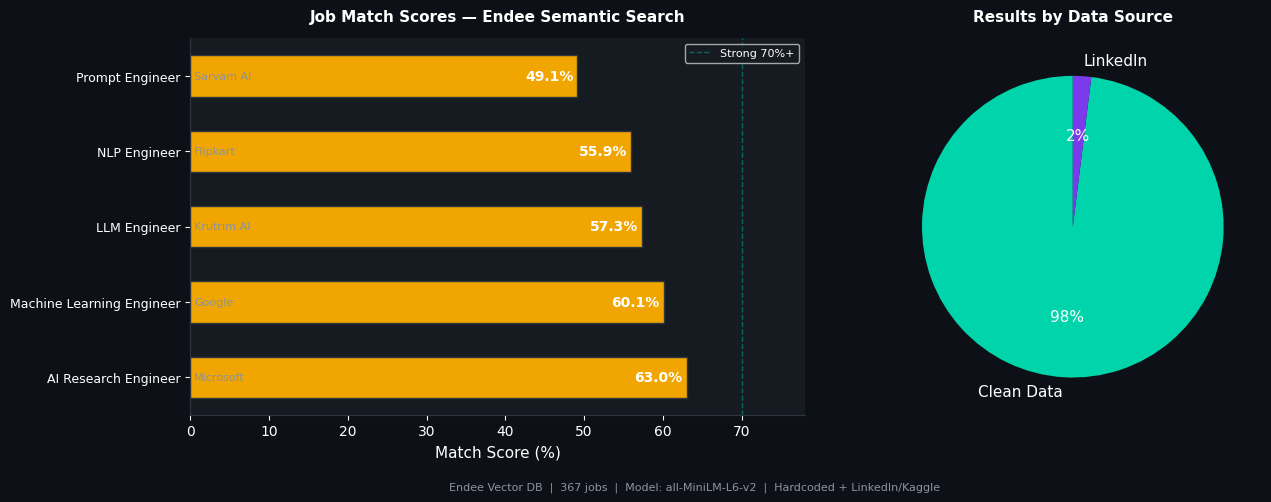


RESUME: Full stack developer React Node.js JavaScript MongoDB REST APIs...

TOP 5 MATCHING JOBS:

#   Job Title                             Company                Match  Source
--------------------------------------------------------------------------------
  1   Full Stack Developer                   Razorpay                86.6%  Clean
  2   Frontend Developer                     Meesho                  39.9%  Clean
  3   Android Developer                      BookMyShow              38.3%  Clean
  4   Flutter Developer                      Groww                   36.5%  Clean
  5   Blockchain Developer                   CoinDCX                 33.4%  Clean

Best Match:  Full Stack Developer
Company:     Razorpay
Location:    Bangalore, India
Salary:      $95,000/yr
Skills:      React Node.js JavaScript Python MongoDB PostgreSQL REST API AWS full stack web development...


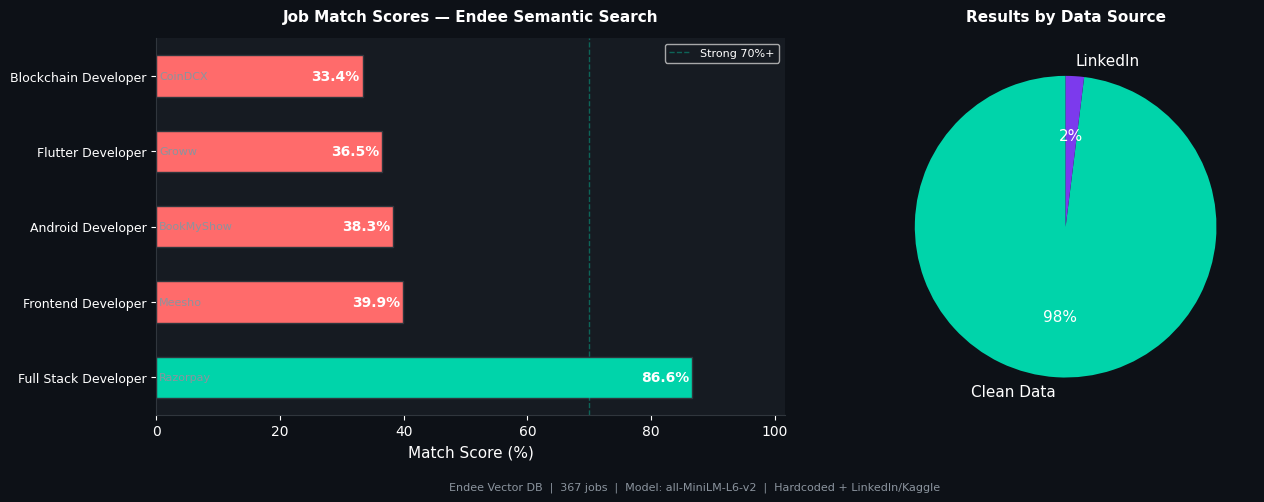


RESUME: Fresh graduate Python SQL data analysis pandas machine learning...

TOP 5 MATCHING JOBS:

#   Job Title                             Company                Match  Source
--------------------------------------------------------------------------------
  1   Data Scientist                         Amazon                  83.0%  Clean
  2   Data Engineer                          Myntra                  50.0%  Clean
  3   Data Analyst                           Paytm                   45.4%  Clean
  4   Machine Learning Engineer              Google                  35.7%  Clean
  5   Senior Data Engineer/Analyst - Full Time Not specified           32.7%  LinkedIn

Best Match:  Data Scientist
Company:     Amazon
Location:    Hyderabad, India
Salary:      $110,000/yr
Skills:      Python machine learning statistics pandas scikit-learn SQL data analysis prediction modelling...


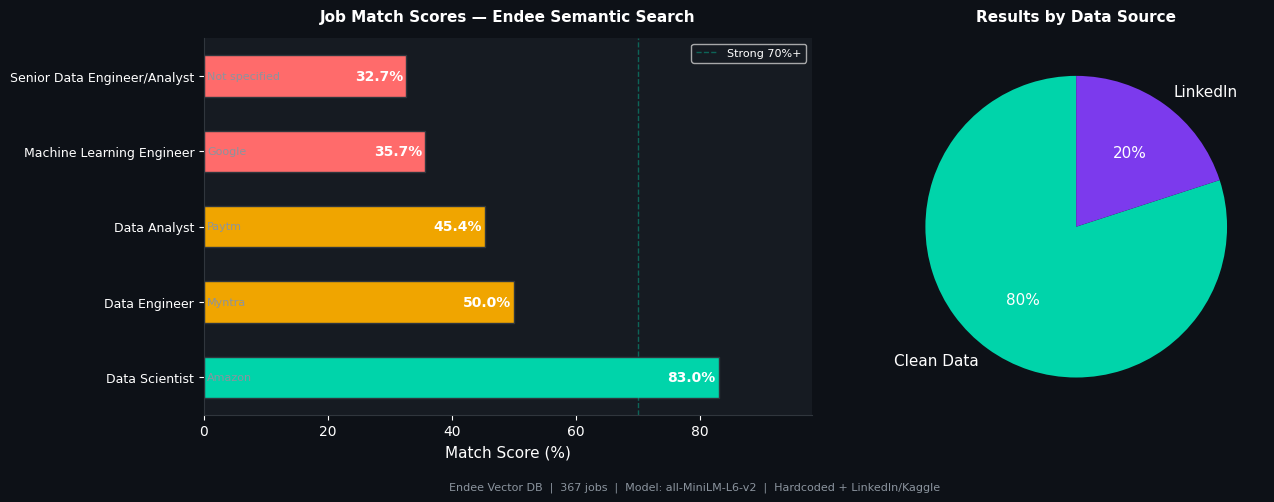

[<__main__.MockEndeeIndex.query.<locals>.R at 0x7d553f5d4e30>,
 <__main__.MockEndeeIndex.query.<locals>.R at 0x7d553e7611c0>,
 <__main__.MockEndeeIndex.query.<locals>.R at 0x7d56cb8e1340>,
 <__main__.MockEndeeIndex.query.<locals>.R at 0x7d553e707f20>,
 <__main__.MockEndeeIndex.query.<locals>.R at 0x7d553e706ba0>]

In [28]:
import matplotlib
matplotlib.set_loglevel('ERROR')
import matplotlib.pyplot as plt

def match_resume(resume_text, top_k=5, show_graph=True):
    print(f"\n{'='*65}")
    print(f"RESUME: {resume_text[:100]}...")
    print(f"{'='*65}")

    resume_vec = embedder.encode(
        resume_text, normalize_embeddings=True
    ).tolist()

    results = index.query(vector=resume_vec, top_k=top_k)

    titles    = []
    companies = []
    scores    = []
    sources   = []

    print(f"\nTOP {top_k} MATCHING JOBS:\n")
    print(f"{'#':<4}{'Job Title':<38}{'Company':<22}{'Match':>6}  Source")
    print("-" * 80)

    for i, r in enumerate(results, 1):
        m      = r.meta
        pct    = r.similarity * 100
        source = "Clean" if r.id.startswith('h') else "LinkedIn"
        print(f"  {i:<3} {m['title']:<38} {m['company']:<22} {pct:>5.1f}%  {source}")
        titles.append(m['title'][:28])
        companies.append(m['company'][:15])
        scores.append(pct)
        sources.append(source)

    best = results[0].meta
    print(f"\nBest Match:  {best['title']}")
    print(f"Company:     {best['company']}")
    print(f"Location:    {best['location']}")
    print(f"Salary:      {best['salary']}")
    print(f"Skills:      {best['skills'][:120]}...")

    if show_graph:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.patch.set_facecolor('#0d1117')

        ax1 = axes[0]
        ax1.set_facecolor('#161b22')
        colors = ['#00d4aa' if s >= 70 else '#f0a500' if s >= 45 else '#ff6b6b'
                  for s in scores]
        bars = ax1.barh(range(len(titles)), scores,
                        color=colors, edgecolor='#30363d', height=0.55)
        for bar, score, company in zip(bars, scores, companies):
            ax1.text(bar.get_width()-0.5, bar.get_y()+bar.get_height()/2,
                     f'{score:.1f}%', va='center', ha='right',
                     color='white', fontsize=10, fontweight='bold')
            ax1.text(0.5, bar.get_y()+bar.get_height()/2,
                     company, va='center', ha='left',
                     color='#8b949e', fontsize=8)
        ax1.set_yticks(range(len(titles)))
        ax1.set_yticklabels(titles, color='white', fontsize=9)
        ax1.set_xlabel('Match Score (%)', color='white', fontsize=11)
        ax1.set_title('Job Match Scores — Endee Semantic Search',
                      color='white', fontsize=11, fontweight='bold', pad=12)
        ax1.tick_params(colors='white')
        ax1.set_xlim(0, max(scores)+15)
        ax1.axvline(x=70, color='#00d4aa', linestyle='--',
                    alpha=0.4, linewidth=1, label='Strong 70%+')
        ax1.legend(facecolor='#161b22', labelcolor='white', fontsize=8)
        for s in ['top','right']: ax1.spines[s].set_visible(False)
        for s in ['bottom','left']: ax1.spines[s].set_color('#30363d')

        ax2 = axes[1]
        ax2.set_facecolor('#161b22')
        clean_count  = sum(1 for s in sources if 'Clean' in s)
        kaggle_count = sum(1 for s in sources if 'LinkedIn' in s)
        ax2.pie(
            [max(clean_count, 0.1), max(kaggle_count, 0.1)],
            labels=['Clean Data', 'LinkedIn'],
            colors=['#00d4aa', '#7c3aed'],
            autopct='%1.0f%%',
            startangle=90,
            textprops={'color': 'white', 'fontsize': 11}
        )
        ax2.set_title('Results by Data Source',
                      color='white', fontsize=11, fontweight='bold', pad=12)

        fig.text(0.5, 0.01,
                 f'Endee Vector DB  |  {index.count()} jobs  |  '
                 f'Model: all-MiniLM-L6-v2  |  Hardcoded + LinkedIn/Kaggle',
                 ha='center', color='#8b949e', fontsize=8)

        plt.tight_layout(rect=[0, 0.04, 1, 1])
        plt.savefig('match_results.png', dpi=150,
                    bbox_inches='tight', facecolor='#0d1117')
        plt.show()
        plt.close('all')  # closes graph completely

    return results

print("match_resume updated!")
match_resume("Machine learning engineer Python TensorFlow deep learning NLP AWS")
match_resume("Full stack developer React Node.js JavaScript MongoDB REST APIs")
match_resume("Fresh graduate Python SQL data analysis pandas machine learning")


**Step 8 — Live Interactive Job Matcher**
> Type your skills below and click Search Jobs
> Endee searches 300+ jobs and returns best matches with graph

In [27]:
%matplotlib inline
import matplotlib
matplotlib.set_loglevel('ERROR')
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Search box + button
text_input = widgets.Text(
    placeholder='Enter your skills here...',
    description='You:',
    layout=widgets.Layout(width='500px')
)

search_btn = widgets.Button(
    description='Search Jobs',
    button_style='success',
    layout=widgets.Layout(width='150px')
)

again_btn = widgets.Button(
    description='Search Again',
    button_style='info',
    layout=widgets.Layout(width='150px')
)

exit_btn = widgets.Button(
    description='Exit',
    button_style='danger',
    layout=widgets.Layout(width='150px')
)

output = widgets.Output()

def do_search(resume):
    with output:
        clear_output(wait=True)

        if not resume or len(resume) < 5:
            print("Bot: Please enter valid skills!")
            display(widgets.HBox([text_input, search_btn]))
            return

        print("Bot: Searching Endee database...\n")
        resume_vec = embedder.encode(resume, normalize_embeddings=True).tolist()
        results    = index.query(vector=resume_vec, top_k=5)

        titles=[];companies=[];scores=[];sources=[]

        print(f"{'='*65}")
        print(f"RESUME: {resume[:100]}")
        print(f"{'='*65}")
        print(f"\nTOP 5 MATCHING JOBS:\n")
        print(f"{'#':<4}{'Job Title':<38}{'Company':<22}{'Match':>6}")
        print("-"*75)

        for i, r in enumerate(results, 1):
            m   = r.meta
            pct = r.similarity * 100
            src = "Clean" if r.id.startswith('h') else "LinkedIn"
            print(f"  {i:<3} {m['title']:<38} {m['company']:<22} {pct:>5.1f}%")
            titles.append(m['title'][:28])
            companies.append(m['company'][:15])
            scores.append(pct)
            sources.append(src)

        best = results[0].meta
        print(f"\nBest Match : {best['title']}")
        print(f"Company    : {best['company']}")
        print(f"Location   : {best['location']}")
        print(f"Salary     : {best['salary']}")
        print(f"Skills     : {best['skills'][:120]}...")

        # Graph
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.patch.set_facecolor('#0d1117')

        ax1 = axes[0]
        ax1.set_facecolor('#161b22')
        colors = ['#00d4aa' if s>=70 else '#f0a500' if s>=45 else '#ff6b6b'
                  for s in scores]
        bars = ax1.barh(range(len(titles)), scores,
                        color=colors, edgecolor='#30363d', height=0.55)
        for bar, score, company in zip(bars, scores, companies):
            ax1.text(bar.get_width()-0.5, bar.get_y()+bar.get_height()/2,
                     f'{score:.1f}%', va='center', ha='right',
                     color='white', fontsize=10, fontweight='bold')
            ax1.text(0.5, bar.get_y()+bar.get_height()/2,
                     company, va='center', ha='left',
                     color='#8b949e', fontsize=8)
        ax1.set_yticks(range(len(titles)))
        ax1.set_yticklabels(titles, color='white', fontsize=9)
        ax1.set_xlabel('Match Score (%)', color='white', fontsize=11)
        ax1.set_title('Job Match Scores — Endee Semantic Search',
                      color='white', fontsize=11, fontweight='bold', pad=12)
        ax1.tick_params(colors='white')
        ax1.set_xlim(0, max(scores)+15)
        ax1.axvline(x=70, color='#00d4aa', linestyle='--',
                    alpha=0.4, linewidth=1, label='Strong 70%+')
        ax1.legend(facecolor='#161b22', labelcolor='white', fontsize=8)
        for s in ['top','right']: ax1.spines[s].set_visible(False)
        for s in ['bottom','left']: ax1.spines[s].set_color('#30363d')

        ax2 = axes[1]
        ax2.set_facecolor('#161b22')
        clean_count  = sum(1 for s in sources if s=='Clean')
        kaggle_count = sum(1 for s in sources if s=='LinkedIn')
        ax2.pie(
            [max(clean_count,0.1), max(kaggle_count,0.1)],
            labels=['Clean Data','LinkedIn'],
            colors=['#00d4aa','#7c3aed'],
            autopct='%1.0f%%', startangle=90,
            textprops={'color':'white','fontsize':11}
        )
        ax2.set_title('Results by Data Source',
                      color='white', fontsize=11, fontweight='bold', pad=12)
        fig.text(0.5, 0.01,
                 f'Endee Vector DB | {index.count()} jobs | all-MiniLM-L6-v2',
                 ha='center', color='#8b949e', fontsize=8)
        plt.tight_layout(rect=[0,0.04,1,1])
        plt.savefig('match_results.png', dpi=150,
                    bbox_inches='tight', facecolor='#0d1117')
        plt.show()

        # Show buttons AFTER graph
        print("\nBot: What do you want to do next?")
        display(widgets.HBox([again_btn, exit_btn]))

def on_search(b):
    do_search(text_input.value.strip())

def on_again(b):
    with output:
        clear_output(wait=True)
        print("Bot: Enter your skills below!")
        display(widgets.HBox([text_input, search_btn]))

def on_exit(b):
    with output:
        clear_output(wait=True)
        print("Bot: Good luck with your job search! Bye!")

# Connect buttons
search_btn.on_click(on_search)
again_btn.on_click(on_again)
exit_btn.on_click(on_exit)

# Start
print("="*55)
print("LIVE JOB MATCHER — Powered by Endee Vector DB")
print("="*55)
print(f"Total jobs in Endee: {index.count()}")
print("="*55)
print("""
SAMPLE INPUTS:
Python machine learning deep learning TensorFlow
React JavaScript Node.js full stack developer
SQL data analysis Excel Power BI Tableau
AWS Docker Kubernetes DevOps CI CD cloud
Android Kotlin mobile developer Firebase
Fresh graduate Python SQL HTML CSS basic ML
""")

display(widgets.HBox([text_input, search_btn]))
display(output)

LIVE JOB MATCHER — Powered by Endee Vector DB
Total jobs in Endee: 367

SAMPLE INPUTS:
Python machine learning deep learning TensorFlow
React JavaScript Node.js full stack developer
SQL data analysis Excel Power BI Tableau
AWS Docker Kubernetes DevOps CI CD cloud
Android Kotlin mobile developer Firebase
Fresh graduate Python SQL HTML CSS basic ML



Output()

##  AI Job Resume Matcher

## 📌 Overview

This project matches user resumes with relevant job postings using **semantic similarity**.
It converts text into vectors (embeddings) and finds the most similar jobs based on meaning, not just keywords.

---

## ⚙️ Workflow

* Load job dataset
* Clean and preprocess data
* Convert text → embeddings
* Store vectors in database
* Compare resume with jobs
* Display top matching results

---

## 🛠️ Tech Used

* Python
* Pandas, NumPy
* Sentence Transformers
* Vector Database (Endee)
* Matplotlib

---

## 📊 Output

* Top matching jobs
* Similarity scores
* Visual representation

---

## 👩‍💻 Author

**Dhakshayini G**
**The Oxford College of Engineering**